### Comparing results of Bayesian DRO experiment with the LSE fix vs the original code script

The goal is to inspect the effect of the following warnings on the optimisation output: 

- `RuntimeWarning: overflow encountered in exp np.mean(np.exp(cost(x, xi[theta_index, :]) / lam))`
- `RuntimeWarning: invalid value encountered in subtract df = fun(x) - f0`



The set-up is the following:

- We run `Bayesian_DRO_continuous.py` which calls the `main_Bayesian_DRO` function twice for each replication of the experiment; once with the option `lse=False` which reproduces the script given to us by the authors and once with `lse=True` which calculates `Bayesian_DRO_1` with Log-Sum-Exp. 
- For each replication, we run function `main_Bayesian_DRO` in parallel using the joblib Parallel class. We did this to speed up the computation.
- We did not run `main_DRO`, `main_empirical`, `main_Bayesian_DRO_epsilon1`, `main_Bayesian_DRO_epsilon2`, `main_Bayesian_DRO_epsilon3`, and `main_empirical_DRO_Wasserstein`.
- To match Section 4.1, we set `b = 8`, `my_mean = 10`, and `my_std = 10`.
- For each replication, we save a CSV file containing the solution and cost for each epsilon via a pandas dataframe. Each replication file is called `result_k.csv`, where `k` is the replication number.


Imports

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bayesian_dro.Bayesian_DRO_continuous import cost, data_generation, EPSILON_SET

/tmp/dcs-tmp.u1604520/ipykernel_562827/1276062597.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Load results from csv files

In [3]:
experiment_dir = Path(f"/dcs/pg23/u1604520/misdro/results_lse")
assert experiment_dir.exists()
replication = 200
results_df = pd.concat([pd.read_csv(experiment_dir / f"result_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon"])
results_df

Unnamed: 0  bayesian_dro_sol  bayesian_dro_cost  \
replication epsilon                                                    
0           0.001             0             17.83          14.652324   
            0.002             1             18.09          15.432324   
            0.005             2             18.53          16.752324   
            0.010             3             19.03          18.252324   
            0.020             4             19.89          20.832324   
...                         ...               ...                ...   
199         1.000            13             39.74          89.209369   
            1.500            14             41.49          94.459369   
            2.000            15             44.92         104.749369   
            2.500            16             50.00         119.989369   
            3.000            17             50.00         119.989369   

                     bayesian_dro_lse_sol  bayesian_dro_lse_cost  
replication epsilon                                               
0           0.001                   17.87              14.772324  
            0.002                   18.09              15.432324  
            0.005                   18.53              16.752324  
            0.010                   19.04              18.282324  
            0.020                   19.85              20.712324  
...                                   ...                    ...  
199         1.000                   41.51              94.519369  
            1.500                   47.80             113.389369  
            2.000                   50.00             119.989369  
            2.500                   50.00             119.989369  
            3.000                   50.00             119.989369  

[3600 rows x 5 columns]

Check how many rows match

In [4]:
print(f'Number of rows for which costs match: {np.sum(np.isclose(results_df["bayesian_dro_cost"], results_df["bayesian_dro_lse_cost"]))}')
print(f'Number of rows for which solutions match: {np.sum(np.isclose(results_df["bayesian_dro_sol"], results_df["bayesian_dro_lse_sol"]))}')
print(f'Total number of rows: {results_df.shape[0]}')


Number of rows for which costs match: 800
Number of rows for which solutions match: 800
Total number of rows: 3600


Calculate out-of-sample means and variances

We have concatenated all the CSV files together, then grouped by $\epsilon$.
In each replication $j = 1,\ldots,K$, we are given $N+M$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}, \ldots, \xi_{N+M}^{(j)}$ where the first $N$ points are the training samples and the last $M$ points are the test sample.
For each $\epsilon$ and each replication $j$, we calculate the out-of-sample mean $\mu^{(j)}(\epsilon)$ and variance $v^{(j)}(\epsilon)$ of the objective function under the $M$ test points:
$$
    \mu^{(j)}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M}~\sum_{i=1}^{M}~{G(x^{(j)}(\epsilon), \xi_{i}^{(j)})} \\
    v^{(j)}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M-1}~\sum_{i=1}^{M}~{\left(G(x^{(j)}(\epsilon), \xi_{i}^{(j)}) - \mu^{(j)}(\epsilon)\right)^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution on replication $j = 1,\ldots,K$.
Over all replications, we then calculate $\hat{\mu}_M(\epsilon)$ and $\hat{v}_M(\epsilon)$, where
$\hat{\mu}_M(\epsilon)$ is the mean-of-the-means,
and $\hat{v}_M(\epsilon)$ is the mean-of-the-variances plus the variance-of-the-means.
$$
    \hat{\mu}_M(\epsilon) :=  \frac{1}{K}~\sum_{j=1}^{K}~{ \mu^{(j)}(\epsilon)}, \\
    \hat{v}_M(\epsilon) := \underbrace{\frac{1}{K}~\sum_{j=1}^{K}~{v^{(j)}(\epsilon)}}_{\text{mean-of-the-variances}} + \underbrace{\frac{1}{K-1}~\sum_{j=1}^{K}~{\left( \mu^{(j)}(\epsilon) - \hat{\mu}_M(\epsilon) \right)^2}}_{\text{variance-of-the-means}}.
$$
Note that setting $M=1$ recovers the out-of-sample mean and variance in the usual way.

In [6]:
# NOTE! the BDRO paper only includes values of epsilon <=0.6
# Here I change this a little bit because we have 1 test point so in-group variances are zero

bdro_results_df = results_df #[results_df.index.get_level_values("epsilon") <= 0.6]

# group by epsilon and replication to get the mean and variance of each replication $j$
bdro_gb = bdro_results_df.groupby(by=["epsilon", "replication"])
bdro_mean_df = bdro_gb.mean()
bdro_var_df = bdro_gb.var()

# get the mean of the means
bdro_mean_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_cost"].mean()
bdro_lse_mean_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_lse_cost"].mean()

# get the mean of the variances
#bdro_mean_of_vars = bdro_var_df.groupby("epsilon")["bayesian_dro_cost"].mean()
#bdro_lse_mean_of_vars = bdro_var_df.groupby("epsilon")["bayesian_dro_lse_cost"].mean()

# variance of the means
bdro_var_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_cost"].var()
bdro_lse_var_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_lse_cost"].var()

# mean of the variances + variance of the means (as in the BDRO paper)
bdro_paper_var = bdro_var_of_means #bdro_mean_of_vars + bdro_var_of_means
bdro_lse_paper_var =  bdro_lse_var_of_means #bdro_lse_mean_of_vars + bdro_lse_var_of_means

Check for how many values of $\epsilon$ the out-of-sample means and variances match

In [7]:
print(f'Number of epsilons for which out-of-sample means match: {np.sum(np.isclose(bdro_mean_of_means, bdro_lse_mean_of_means))}')
print(f'Number of rows for which solutions match: {np.sum(np.isclose(bdro_paper_var, bdro_lse_paper_var))}')
print(f'Total number of epsilons: {len(bdro_mean_of_means)}')

Number of epsilons for which out-of-sample means match: 4
Number of rows for which solutions match: 6
Total number of epsilons: 18


Plot results

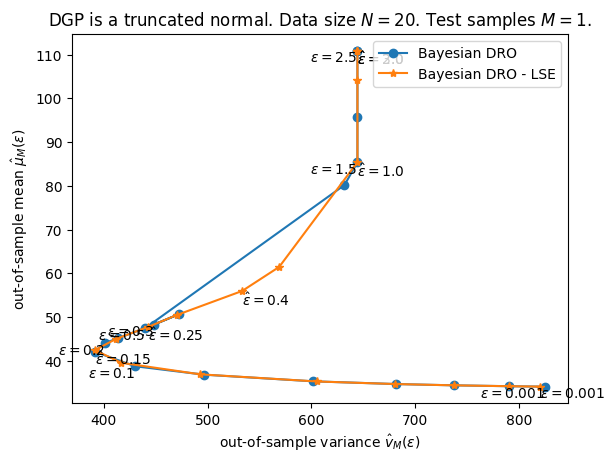

In [9]:
plt.plot(bdro_paper_var, bdro_mean_of_means, marker='o', label="Bayesian DRO")
plt.plot(bdro_lse_paper_var, bdro_lse_mean_of_means, marker='*', label="Bayesian DRO - LSE")

X_LABEL = "out-of-sample variance $\hat{v}_{M}(\epsilon)$"
Y_LABEL = "out-of-sample mean $\hat{\mu}_{M}(\epsilon)$"
plt.title(f"DGP is a truncated normal. Data size $N = 20$. Test samples $M=1$.")
plt.legend()
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)

for i, epsilon in enumerate(bdro_mean_of_means.index.values):
    if i % 2 == 0 and epsilon >= 0.1:
        plt.text(bdro_paper_var.iloc[i], bdro_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='right', va='top')
    
    elif epsilon == 0.001:
        plt.text(bdro_paper_var.iloc[i], bdro_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='right', va='top')

for i, epsilon in enumerate(bdro_lse_mean_of_means.index.values):
    if i % 2 == 1 and epsilon >= 0.1:
        plt.text(bdro_lse_paper_var.iloc[i], bdro_lse_mean_of_means.iloc[i], f"$\hat{{\epsilon}}={epsilon}$", ha='left', va='top')
        
    elif epsilon == 0.001:
        plt.text(bdro_lse_paper_var.iloc[i], bdro_lse_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
    